In [2]:
#load dataset
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#basic eda
df.shape

(891, 12)

In [4]:
#basic eda
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
#basic eda
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
#basic eda: statistical summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
#basic eda: missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
df.duplicated().sum()

np.int64(0)

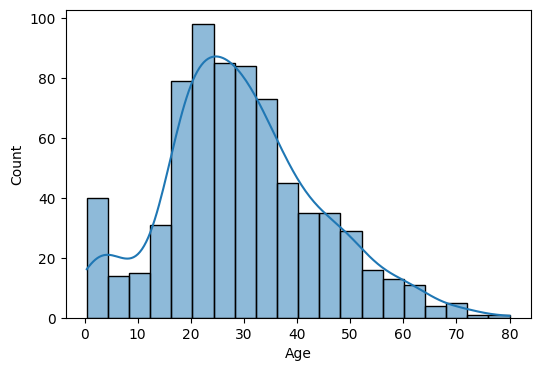

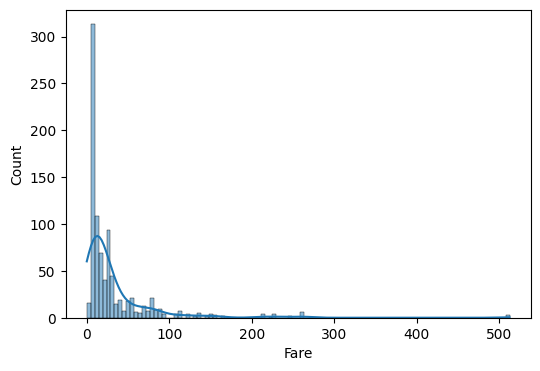

In [10]:
#univariate analysis
#numerical columns

num_cols = ['Age', 'Fare']

for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col], kde=True)
  plt.show()

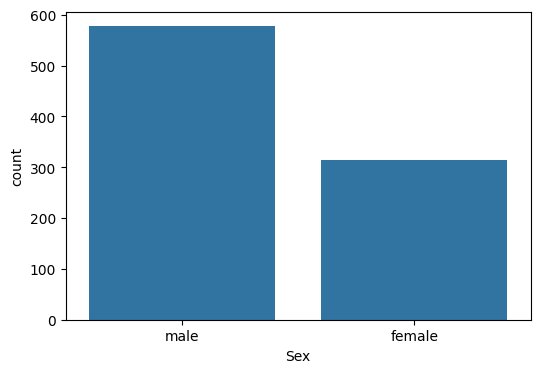

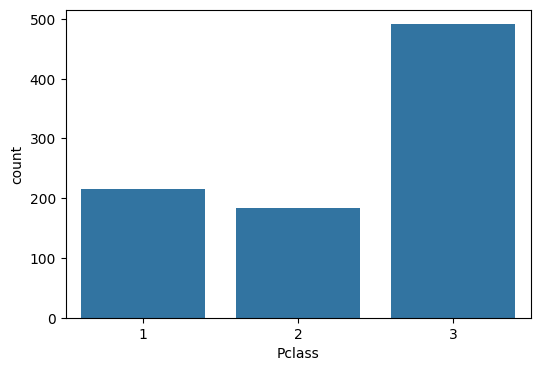

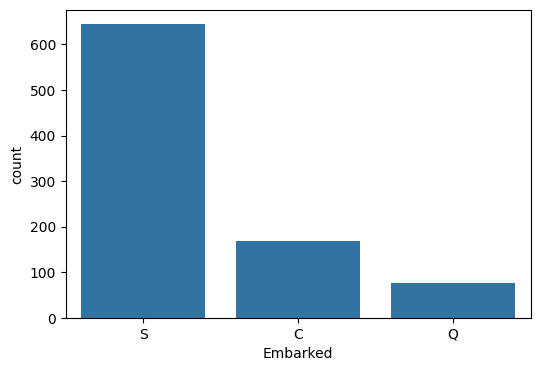

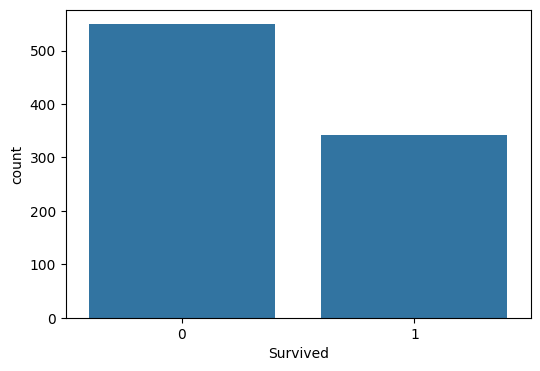

In [11]:
#univariate analysis
#categorical columns
cat_cols = ['Sex', 'Pclass', 'Embarked', 'Survived']

for col in cat_cols:
  plt.figure(figsize=(6,4))
  sns.countplot(x = df[col])
  plt.show()

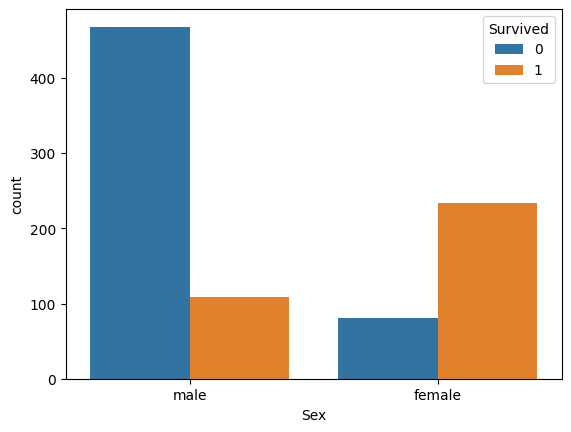

In [12]:
#Bivariate analysis
#survival vs gender
sns.countplot(x ='Sex', hue = 'Survived', data=df)
plt.show()

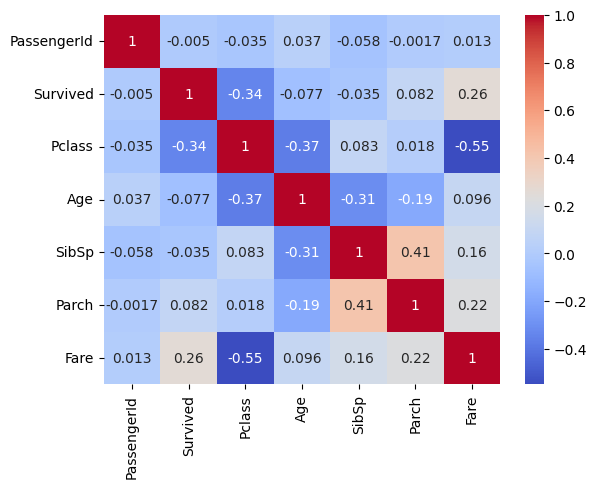

In [13]:
#bivariate analysis
#Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [14]:
#data cleaning
df_cleaned = df.copy()

In [15]:
#handle missing values
df_cleaned.isnull().sum()

#Age: use median:
df_cleaned['Age'].fillna(
    df_cleaned['Age'].median(), inplace=True
)

#Embarked: use mode:
df_cleaned['Embarked'].fillna(
    df_cleaned['Embarked'].mode()[0], inplace = True
)

#Cabin: drop because too many missing values:
df_cleaned.drop('Cabin', axis = 1,inplace = True)

#check again
df_cleaned.isnull().sum()

/tmp/ipykernel_937/2531510998.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['Age'].fillna(
/tmp/ipykernel_937/2531510998.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: v

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [17]:
#Remove duplicates
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape

(891, 11)

In [19]:
#fix data types
#check
df_cleaned.dtypes

#convert if needed
df_cleaned['Survived'] = df_cleaned['Survived'].astype(int)

In [20]:
#handle categories
#check:
df_cleaned['Sex'].value_counts()


,count
Sex,
male,577
female,314


In [21]:
#handle categories
#check:
df_cleaned['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


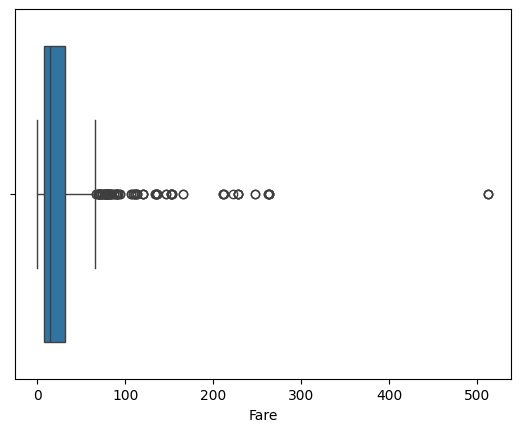

In [22]:
#Outlier detection
#boxplot
sns.boxplot(x=df_cleaned['Fare'])
plt.show()

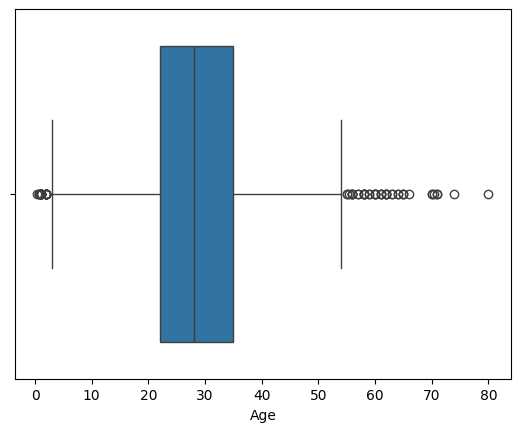

In [23]:
#Outlier detection
#boxplot
sns.boxplot(x=df_cleaned['Age'])
plt.show()

In [25]:
#Outlier detection
#IQR method
Q1 = df_cleaned['Fare'].quantile(0.25)
Q3 = df_cleaned['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower =Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_cleaned = df_cleaned[
    (df_cleaned['Fare'] >= lower) & (df_cleaned['Fare'] <= upper)
]

In [ ]:
#Encoding: Label Encoding
#Sex

df_cleaned['Sex'] = df_cleaned['Sex'].map({
    'male': 0,
    'female':1
    })

In [26]:
#Encoding: One Hot Encoding
#Embarked
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns = ['Embarked'],
    drop_first = True
)

In [30]:
#feature engineering

#family size
df_cleaned['FamilySize'] = (
    df_cleaned['SibSp'] +
    df_cleaned['Parch'] + 1
)

#Is Alone
df_cleaned['IsAlone'] = np.where(
    df_cleaned['FamilySize']==1, 1, 0
)

df_cleaned['Title'] = (
    df_cleaned['Name']
    .str.extract(' ([A-Za-z]+)\.',
                 expand=False)
)
#check
df_cleaned['Title'].value_counts()

df_cleaned['Title'] = df_cleaned['Title'].replace(
[
'Lady','Countess','Capt',
'Col','Don','Dr','Major',
'Rev','Sir','Jonkheer','Dona'
],
'Rare'
)

#Map
df_cleaned['Title'] = df_cleaned['Title'].map({'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4})

df_cleaned['AgeGroup'] = pd.cut(
    df_cleaned['Age'],
    bins=[0,12,18,35,60,100],
    labels=[0,1,2,3,4]
)

<>:16: SyntaxWarning: invalid escape sequence '\.'
<>:16: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_937/3701706119.py:16: SyntaxWarning: invalid escape sequence '\.'
  .str.extract(' ([A-Za-z]+)\.',


In [31]:
#Drop unnecessary columns
df_cleaned.drop(
    ['PassengerId', 'Name', 'Ticket', 'Age', 'Fare'],
    axis=1,
    inplace=True
)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = [
'Age',
'Fare',
'FamilySize'
]

df_cleaned[cols] = scaler.fit_transform(
    df_cleaned[cols]
)

KeyError: "['Age', 'Fare'] not in index"

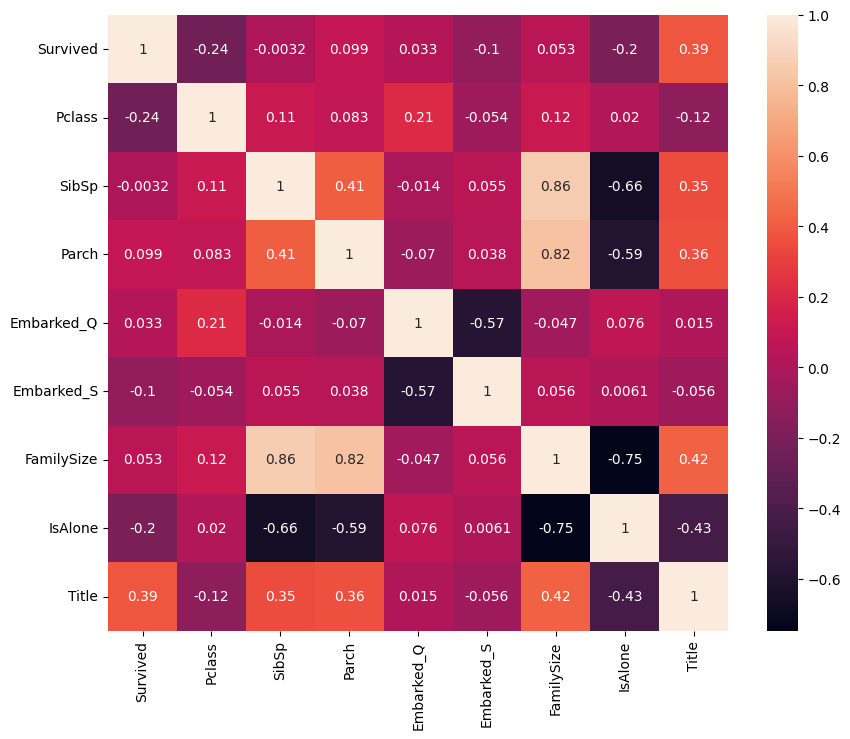

,Survived
Survived,1.000000
Title,0.385562
Parch,0.098575
FamilySize,0.052674
Embarked_Q,0.032707
SibSp,-0.003156
Embarked_S,-0.102337
IsAlone,-0.198104
Pclass,-0.238532


In [35]:
#Feature selection
corr = df_cleaned.corr(
    numeric_only = True
)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot = True)
plt.show()

#correlation with Target
corr['Survived'].sort_values(ascending=False)

In [36]:
#create final dataset
X = df_cleaned.drop('Survived', axis = 1)
y = df_cleaned['Survived']

In [37]:
#Train-Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
#Train model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

ValueError: could not convert string to float: 'female'

In [41]:
#Evaluation
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)

accuracy_score(y_test,pred)

AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'

In [42]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    pred
))

NameError: name 'pred' is not defined